In [1]:
import numpy as np
import rasterio

dem_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/georef/DEM_JZ_1m.tiff"

with rasterio.open(dem_path) as src:
    dem = src.read(1).astype(np.float32)

print("Shape:", dem.shape)
print("Dtype:", dem.dtype)
print("Min:", np.nanmin(dem))
print("Max:", np.nanmax(dem))
print("Has NaN:", np.isnan(dem).any())
print("Example values:", dem[100:105, 100:105])


Shape: (18040, 15003)
Dtype: float32
Min: 158.0158
Max: 3.4e+38
Has NaN: False
Example values: [[209.54613 209.57355 209.6269  209.63113 209.59306]
 [209.51077 209.5457  209.58055 209.60901 209.60587]
 [209.46889 209.5745  209.60553 209.5717  209.60246]
 [209.49884 209.54637 209.59029 209.574   209.52275]
 [209.57199 209.55339 209.5612  209.58969 209.5126 ]]


In [2]:
dem_clean = dem.copy()

# удаляем явные переполнения
dem_clean[dem_clean > 1e10] = np.nan
dem_clean[dem_clean < -1000] = np.nan

# получаем статистику только по нормальным значениям
p1, p99 = np.nanpercentile(dem_clean, [1, 99])
print("p1:", p1, "p99:", p99)

p1: 162.12359619140625 p99: 314.49810791015625


In [3]:
valid = (dem >= p1-10) & (dem <= p99+60)

In [4]:
dem_fixed = dem.copy()
dem_fixed[~valid] = np.nan

In [6]:
print(np.nanmax(dem_fixed))
print(np.nanmin(dem_fixed))


370.33685
158.0158


In [ ]:
dem[~valid] = -1
to_save = {
    "dem": dem,
    "valid": valid,
}
np.savez_compressed("/home/nc225mj/lidar-archaeology-segmentation/data/processed/DEM_JZ_1cm.npz", **to_save)

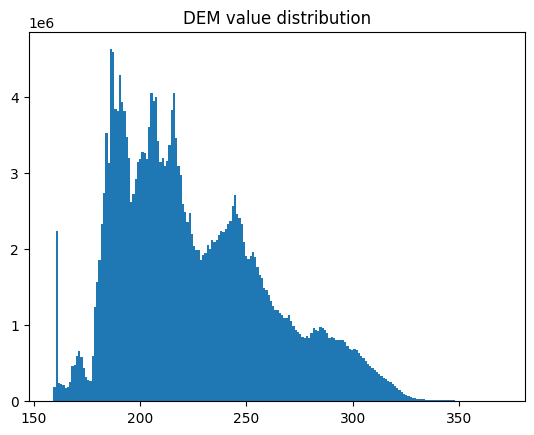

In [7]:
import matplotlib.pyplot as plt

plt.hist(dem_fixed.flatten(), bins=200)
plt.title("DEM value distribution")
plt.show()

In [3]:
bad = dem > 1000   # любые высоты >10 км — мусор
np.sum(bad)

np.int64(8422949)

In [7]:
valid = (dem > 0) & (dem < 3000)
valid = valid.astype(np.uint8)

dem[~valid] = -1

In [9]:
print("Min:", np.nanmin(dem))
print("Max:", np.nanmax(dem))

Min: -1.0
Max: 3.4e+38


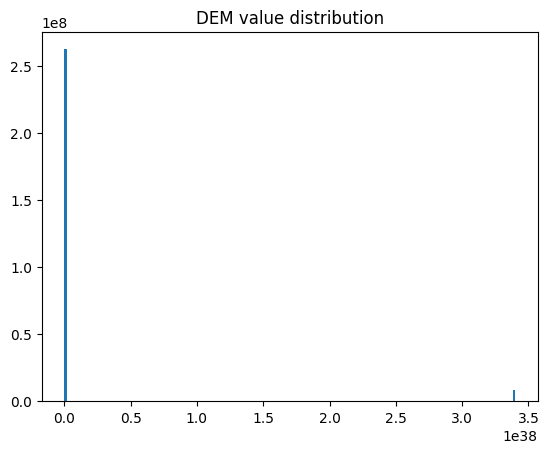

In [8]:
import matplotlib.pyplot as plt

plt.hist(dem.flatten(), bins=200)
plt.title("DEM value distribution")
plt.show()

In [ ]:
import numpy as np
import rasterio

dem_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/georef/DEM_MC_1m.tiff"

with rasterio.open(dem_path) as src:
    print(src.profile)
    dem = src.read(1).astype(np.float32).copy()

print("Shape:", dem.shape)
print("Dtype:", dem.dtype)
print("Min:", np.nanmin(dem))
print("Max:", np.nanmax(dem))
print("Has NaN:", np.isnan(dem).any())
print("Example values:", dem[100:105, 100:105])


{'driver': 'GTiff', 'dtype': 'float32', 'nodata': 0.0, 'width': 47005, 'height': 18005, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(1.0, 0.0, 121997.5,
       0.0, -1.0, 1950002.5), 'blockxsize': 47005, 'blockysize': 1, 'tiled': False, 'interleave': 'band'}
Shape: (18005, 47005)
Dtype: float32
Min: 0.0
Max: 213.93642
Has NaN: False
Example values: [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


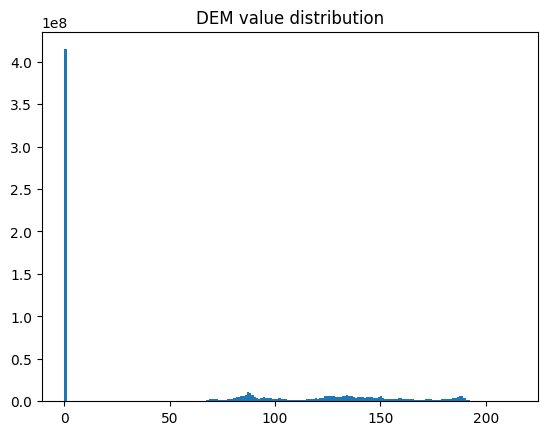

In [2]:
import matplotlib.pyplot as plt

plt.hist(dem.flatten(), bins=200)
plt.title("DEM value distribution")
plt.show()

In [5]:
valid = (dem > 50) & (dem < 250)
valid = valid.astype(np.uint8)

In [6]:
assert valid.shape == dem.shape
print(valid.shape)

(18005, 47005)


In [ ]:
dem = np.where(valid, dem, -1).astype(np.float32)

In [ ]:
dem_norm = np.zeros_like(dem)
dem_norm[valid] = (dem[valid] - dem[valid].min()) / (dem[valid].max() - dem[valid].min())

In [ ]:
to_save = {
    "dem": dem,
    "valid": valid,
}
np.savez_compressed("/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/processed/DEM_MC_1cm.npz", **to_save)

In [ ]:
import matplotlib.pyplot as plt

plt.hist(dem.flatten(), bins=200)
plt.title("DEM value distribution")
plt.show()

In [ ]:
import numpy as np
import rasterio

rgb_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/georef/ldr21_d_STU_General.tif"

with rasterio.open(rgb_path) as src:
    rgb = src.read()
    print("nodata:", src.nodata)
    print("mask flags:", src.mask_flag_enums)
    print("colorinterp:", src.colorinterp)
    mask = src.dataset_mask()
    print(mask.shape, mask.dtype, mask.min(), mask.max())

print("Shape:", rgb.shape)
print("Dtype:", rgb.dtype)

nodata: None
mask flags: ([<MaskFlags.per_dataset: 2>], [<MaskFlags.per_dataset: 2>], [<MaskFlags.per_dataset: 2>])
colorinterp: (<ColorInterp.red: 3>, <ColorInterp.green: 4>, <ColorInterp.blue: 5>)
(34996, 22003) uint8 0 255
Shape: (3, 34996, 22003)
Dtype: uint8


In [1]:
import rasterio

rgb_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/georef/ldr21_d_STU_General.tif"
dem_path = "/home/nikitachernysh/storage/Projects/lidar-archaeology-segmentation/data/georef/DEM.tif"

# 1. Load training area bounding box
with rasterio.open(dem_path) as src_train:
    left, bottom, right, top = src_train.bounds

# 2. Load RGB and compute window
with rasterio.open(rgb_path) as src_rgb:
    window = rasterio.windows.from_bounds(
        left, bottom, right, top,
        transform=src_rgb.transform
    )
    rgb_crop = src_rgb.read(window=window)

# rgb_crop shape = (3, cropped_H, cropped_W)
print("Cropped RGB shape:", rgb_crop.shape)

Cropped RGB shape: (3, 17092, 9791)


In [4]:
rgb[0].shape[0] == dem.shape[0] + 1

True

In [7]:
rgb[0].shape[1] == dem.shape[1] + 1

False

In [4]:
print(mask.max().astype(bool))
print(mask.min().astype(bool))

True
False


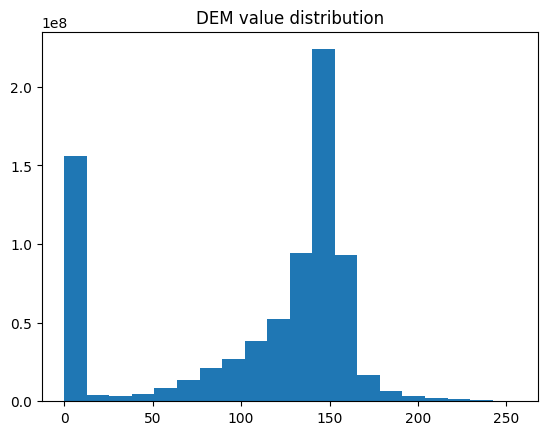

In [2]:
import matplotlib.pyplot as plt

plt.hist(rgb[0].flatten(), bins=20)
plt.title("DEM value distribution")
plt.show()

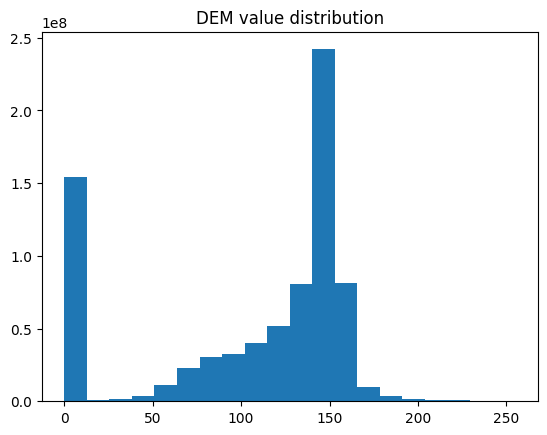

In [3]:
import matplotlib.pyplot as plt

plt.hist(rgb[1].flatten(), bins=20)
plt.title("DEM value distribution")
plt.show()

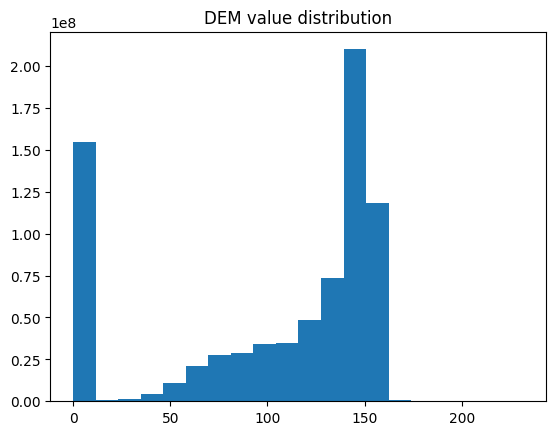

In [4]:
import matplotlib.pyplot as plt

plt.hist(rgb[2].flatten(), bins=20)
plt.title("DEM value distribution")
plt.show()

In [6]:
print(np.sum(rgb[0]<=1))
print(np.sum(rgb[1]<=1))
print(np.sum(rgb[2]<=1))

154426116
154412683
154356785


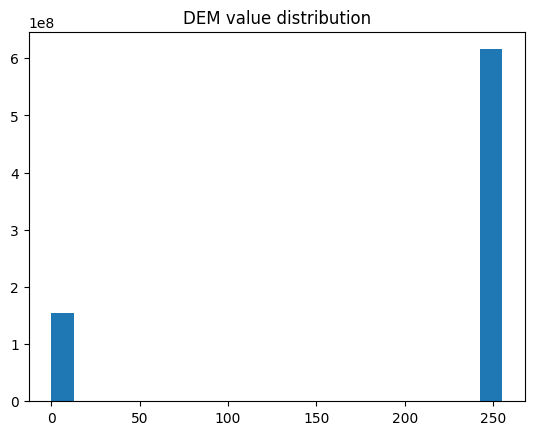

In [2]:
import matplotlib.pyplot as plt

plt.hist(mask.flatten(), bins=20)
plt.title("DEM value distribution")
plt.show()

In [ ]:
rgb = (rgb / 255.0)

KeyboardInterrupt: 